In [20]:
def rdk_bandit_csv_analysis(input_csv):
    import csv
    import copy
    import math
    import pandas
    import statistics
    import matplotlib.pyplot
    from scipy import stats
    ## MAIN CODE ALL ORIGINALLY CODED BY COLEMAN KLAPHEKE
    # load csv into list of lists
    csvFile = open(input_csv, encoding="utf-8")
    csvReader = csv.reader(csvFile)
    csvData = list(csvReader)
    csvFile.close()
    mainData = copy.deepcopy(csvData)
    # header is categories of data
    mainDataHeader = mainData[0]
    # bulk data is list of all trials organized in order of header items
    mainDataBulkData = mainData[1:]
    ## create dictionary for each subject where main key is subject ID, and subsequent keys are categories with lists of the data item for each trial
    subjects_dict = {}
    # loop through each trial
    for trial in mainDataBulkData:
        subject_id = trial[mainDataHeader.index('subject_id')]
        if subject_id not in subjects_dict:
            subjects_dict[subject_id] = {}
            # add age group as key with numerical value 1 = younger than 21, 2 = 22 to 30, 3 = 31 to 50, 4 = older than 50
            if 'Age Group' not in subjects_dict[subject_id]:
                try:
                    age_group = trial[mainDataHeader.index('age_group')]
                    assert age_group != 'N/A'
                    if age_group == '<21':
                        age_numerical = 1
                    if age_group == '22-30':
                        age_numerical = 2
                    if age_group == '31-50':
                        age_numerical = 3
                    if age_group == '>50':
                        age_numerical = 4
                    subjects_dict[subject_id]['Age Group'] = age_numerical
                # one subject did not have age group recorded but it is known
                except AssertionError:
                    if subject_id == 'sub713' or subject_id == 'sub358':
                        subjects_dict[subject_id]['Age Group'] = 4 
            # add gender as key with numerical value 1 = male, 2 = female, 3 = non-binary, 4 = other
            if 'Gender' not in subjects_dict[subject_id]:
                try:
                    gender = trial[mainDataHeader.index('gender')]
                    assert gender != 'N/A'
                    if gender == 'Male':
                        gender_numerical = 1
                    if gender == 'Female':
                        gender_numerical = 2
                    if gender == 'Non-binary':
                        gender_numerical = 3
                    if gender == 'Other':
                        gender_numerical = 4
                    subjects_dict[subject_id]['Gender'] = gender_numerical
                # one subject did not have gender recorded but it is known
                except AssertionError:
                    if subject_id == 'sub713':
                        subjects_dict[subject_id]['Gender'] = 2 
                    elif subject_id == 'sub358':
                        subjects_dict[subject_id]['Gender'] = 1
            # add reward direction as key with numerical value -1 = left, 1 = right, reward direction corresponds to .7 chance of getting a reward vs .3
            if 'Reward Direction' not in subjects_dict[subject_id]:
                reward_direction = trial[mainDataHeader.index('lucky_direction')]
                if reward_direction == 'right':
                    subjects_dict[subject_id]['Reward Direction'] = 1
                if reward_direction == 'left':
                    subjects_dict[subject_id]['Reward Direction'] = -1
            # add coherence as a key corresponding to a list
            if 'Coherence' not in subjects_dict[subject_id]:
                subjects_dict[subject_id]['Coherence'] = []
            # add top box direction as a key corresponding to a list which will have values for each trial
            if 'Top Box Direction' not in subjects_dict[subject_id]:
                subjects_dict[subject_id]['Top Box Direction'] = []
            # add bottom box direction as a key corresponding to a list which will have values for each trial
            if 'Bottom Box Direction' not in subjects_dict[subject_id]:
                subjects_dict[subject_id]['Bottom Box Direction'] = []
            # add chosen box direction as a key corresponding to a list which will have values for each trial
            if 'Chosen Box' not in subjects_dict[subject_id]:
                subjects_dict[subject_id]['Chosen Box'] = []
            # add response time as a key corresponding to a list which will have values for each trial
            if 'Response Time' not in subjects_dict[subject_id]:
                subjects_dict[subject_id]['Response Time'] = []
            # add reward recieved as a key corresponding to a list as to whether a reward was received for that trial where 0 = no reward and 1 = rewarded
            if 'Rewarded' not in subjects_dict[subject_id]:
                subjects_dict[subject_id]['Rewarded'] = []
        # create coherence list as numerical values where 1 = .05, 2 = .15, 3 = .25, 4 = .35
        if trial[mainDataHeader.index('coherence')] == '0.05':
            subjects_dict[subject_id]['Coherence'].append(1)
        if trial[mainDataHeader.index('coherence')] == '0.15':
            subjects_dict[subject_id]['Coherence'].append(2)
        if trial[mainDataHeader.index('coherence')] == '0.25':
            subjects_dict[subject_id]['Coherence'].append(3)
        if trial[mainDataHeader.index('coherence')] == '0.35':
            subjects_dict[subject_id]['Coherence'].append(4)
        # create top box direction and bottoms box direciton lists as numerical values where left = -1, and right = 1
        if trial[mainDataHeader.index('top_direction')] == 'left':
            subjects_dict[subject_id]['Top Box Direction'].append(-1)
            subjects_dict[subject_id]['Bottom Box Direction'].append(1)
        else:
            subjects_dict[subject_id]['Top Box Direction'].append(1)
            subjects_dict[subject_id]['Bottom Box Direction'].append(-1)
        # create chosen box list for each trial where top = 1 and bottom = -1
        if trial[mainDataHeader.index('chosen_box')] == 'top':
            subjects_dict[subject_id]['Chosen Box'].append(1)
        else:
            subjects_dict[subject_id]['Chosen Box'].append(-1)
        # create list of response times(ms) for each trial
        subjects_dict[subject_id]['Response Time'].append(int(trial[mainDataHeader.index('rt_ms')]))
        # create list as to whether a reward was received or not for each trial
        if trial[mainDataHeader.index('reward_received')] == '1':
            subjects_dict[subject_id]['Rewarded'].append(1)
        else:
            subjects_dict[subject_id]['Rewarded'].append(0)
        # add subject to entire dictionary of all subjects and then loop to next subject
        
    # find optimal learning rate for each subject using maximum likelihood estimation
    for subject in subjects_dict:
        highest_log_likelihood = None
        best_learning_rate = None
        for j in range(0, 100, 1):
            learning_rate = j/100
            q_top = .5
            q_bottom = .5
            log_likelihood = 0
        # calculate learning rate for each subject through maximum likelihood estimation
            # loop through trials to determine predictions for ideal choice for each trial
            for i in range(0,len(subjects_dict[subject]['Coherence'])):
                #calculate reward for the trial
                r = subjects_dict[subject]['Rewarded'][i]
                actionValueDifference = q_top - q_bottom
                probability_choose_top = 1 / (1 + ((math.e)**-actionValueDifference))
                if subjects_dict[subject]['Chosen Box'][i] == 1:
                    log_probability = math.log(probability_choose_top)
                    q_top += learning_rate*(r - q_top)
                else:
                    log_probability = math.log((1 - probability_choose_top))
                    q_bottom += learning_rate*(r - q_bottom)
                log_likelihood += log_probability
            if highest_log_likelihood == None or log_likelihood > highest_log_likelihood:
                highest_log_likelihood = log_likelihood
                best_learning_rate = learning_rate
        subjects_dict[subject]['Learning Rate'] = best_learning_rate
        
    #calculate action value differences for each trial and each subject
    for subject in subjects_dict:
        #build list for q_diff values for each trial
        q_diff_list = []
        learning_rate = subjects_dict[subject]['Learning Rate']
        q_top = .5
        q_bottom = .5
        for i in range(0,len(subjects_dict[subject]['Coherence'])):
            r = subjects_dict[subject]['Rewarded'][i]
            actionValueDifference = q_top - q_bottom
            q_diff_list.append(actionValueDifference)
            if subjects_dict[subject]['Chosen Box'][i] == 1:
                q_top += learning_rate*(r - q_top)
            else:
                q_bottom += learning_rate*(r - q_bottom)
        subjects_dict[subject]['Action Value Differences'] = q_diff_list
        
    # calculate sensory signals for each trial for each subject
    for subject in subjects_dict:
        subject_sensory_signals = []
        for i in range(0,len(subjects_dict[subject]['Coherence'])):
            if subjects_dict[subject]['Coherence'][i] == 1:
                coherence = .05
            if subjects_dict[subject]['Coherence'][i] == 2:
                coherence = .15
            if subjects_dict[subject]['Coherence'][i] == 3:
                coherence = .25
            if subjects_dict[subject]['Coherence'][i] == 4:
                coherence = .35
            if subjects_dict[subject]['Top Box Direction'][i] == subjects_dict[subject]['Reward Direction']:
                correct_box_location = 1
            else:
                correct_box_location = -1
            subject_sensory_signals.append(coherence * correct_box_location)
        subjects_dict[subject]['Sensory Signals'] = subject_sensory_signals
        
    # calculate regression coefficients for all subjects and all trials
    for subject in subjects_dict:
        best_log_likelihood_low_coherence = None
        best_beta_RL_low_coherence = None
        best_beta_sensory_low_coherence = None
        best_log_likelihood_high_coherence = None
        best_beta_RL_high_coherence = None
        best_beta_sensory_high_coherence = None
        for j in range(-500, 500, 10):
            beta_reinforcement_learning = j/100
            for i in range(-500,500,10):
                beta_sensory_learning = i/100
                log_likelihood_low_coherence = 0
                log_likelihood_high_coherence = 0
                for i in range(0,len(subjects_dict[subject]['Coherence'])):
                    if subjects_dict[subject]['Coherence'][i] == 1 or subjects_dict[subject]['Coherence'][i] == 2:
                        decision_signal = beta_reinforcement_learning * subjects_dict[subject]['Action Value Differences'][i] + beta_sensory_learning * subjects_dict[subject]['Sensory Signals'][i]
                        probability_choose_top = 1 / (1+((math.e)**(-1 * decision_signal)))
                        if subjects_dict[subject]['Chosen Box'][i] == 1:
                            log_likelihood_low_coherence += math.log(probability_choose_top)
                        else:
                            log_likelihood_low_coherence += math.log(1 - probability_choose_top)
                    if subjects_dict[subject]['Coherence'][i] == 3 or subjects_dict[subject]['Coherence'][i] == 4:
                        decision_signal = beta_reinforcement_learning * subjects_dict[subject]['Action Value Differences'][i] + beta_sensory_learning * subjects_dict[subject]['Sensory Signals'][i]
                        probability_choose_top = 1 / (1+((math.e)**(-1 * decision_signal)))
                        if subjects_dict[subject]['Chosen Box'][i] == 1:
                            log_likelihood_high_coherence += math.log(probability_choose_top)
                        else:
                            log_likelihood_high_coherence += math.log(1 - probability_choose_top)
                if best_log_likelihood_low_coherence == None or log_likelihood_low_coherence > best_log_likelihood_low_coherence:
                        best_log_likelihood_low_coherence = log_likelihood_low_coherence
                        best_beta_RL_low_coherence = beta_reinforcement_learning
                        best_beta_sensory_low_coherence = beta_sensory_learning
                if best_log_likelihood_high_coherence == None or log_likelihood_high_coherence > best_log_likelihood_high_coherence:
                        best_log_likelihood_high_coherence = log_likelihood_high_coherence
                        best_beta_RL_high_coherence = beta_reinforcement_learning
                        best_beta_sensory_high_coherence = beta_sensory_learning
        subjects_dict[subject]['Low Coherence Sensory Regression Coefficient'] = best_beta_sensory_low_coherence
        subjects_dict[subject]['High Coherence Sensory Regression Coefficient'] = best_beta_sensory_high_coherence
        subjects_dict[subject]['Low Coherence Box Location Regression Coefficient'] = best_beta_RL_low_coherence
        subjects_dict[subject]['High Coherence Box Location Regression Coefficient'] = best_beta_RL_high_coherence
        
    # compute whether top or bottom box had the correct motion direction for each trial for each subject with 1 = top box had higher probability of reward or -1 = lower box had higher probability of reward
    for subject in subjects_dict:
        # build list for direction alignments
        choice_direction_list = []
        for i in range(0,len(subjects_dict[subject]['Coherence'])):
            if subjects_dict[subject]['Top Box Direction'][i] == subjects_dict[subject]['Reward Direction']:
                choice_direction_list.append(1)
            else:
                choice_direction_list.append(-1)
        subjects_dict[subject]['Correct Box Location'] = choice_direction_list
        
    # calculate if reward history drove choice behavior for each trial
    for subject in subjects_dict:
        reward_history_vs_choice = []
        for i in range(0,len(subjects_dict[subject]['Coherence'])):
            if subjects_dict[subject]['Action Value Differences'][i] > 0:
                learning_signal = 1
            elif subjects_dict[subject]['Action Value Differences'][i] < 0:
                learning_signal = -1
            elif subjects_dict[subject]['Action Value Differences'][i] == 0:
                learning_signal = None
            if subjects_dict[subject]['Chosen Box'][i] == learning_signal:
                reward_history_vs_choice.append(1)
            elif learning_signal == None:
                reward_history_vs_choice.append(None)
            elif learning_signal != None and subjects_dict[subject]['Chosen Box'][i] != learning_signal:
                reward_history_vs_choice.append(0)
        subjects_dict[subject]['Reward History Alignment'] = reward_history_vs_choice
        
    # calculate if sensory data drove choice behavior for each trial
    for subject in subjects_dict:
        stimulus_direction_vs_choice = []
        for i in range(0,len(subjects_dict[subject]['Coherence'])):
            if subjects_dict[subject]['Chosen Box'][i] == 1:
                if subjects_dict[subject]['Top Box Direction'][i] == subjects_dict[subject]['Reward Direction']:
                    stimulus_direction_vs_choice.append(1)
                else:
                    stimulus_direction_vs_choice.append(0)
            else:
                if subjects_dict[subject]['Bottom Box Direction'][i] == subjects_dict[subject]['Reward Direction']:
                    stimulus_direction_vs_choice.append(1)
                else:
                    stimulus_direction_vs_choice.append(0)
        subjects_dict[subject]['Correct Sensory Data Alignment'] = stimulus_direction_vs_choice
        
    # calculate p-values for reward history influence versus stimulus alignment using paired t test
    reward_history_vs_stimulus_alignment_low_vs_high_coherence_all_subjects = []
    reward_history_vs_stimulus_alignment_low_coherence_all_subjects = []
    reward_history_vs_stimulus_alignment_high_coherence_all_subjects  = []
    N = len(subjects_dict)
    N_no_learning_removed = len(subjects_dict)
    for subject in subjects_dict:
        reward_history_vs_stimulus_alignment_low_coherence = []
        reward_history_vs_stimulus_alignment_high_coherence = []
        for i in range(0,len(subjects_dict[subject]['Coherence'])):
            if subjects_dict[subject]['Reward History Alignment'][i] == None:
                continue
            if subjects_dict[subject]['Coherence'][i] == 1 or subjects_dict[subject]['Coherence'][i] == 2:
                 reward_history_vs_stimulus_alignment_low_coherence.append(subjects_dict[subject]['Reward History Alignment'][i] - subjects_dict[subject]['Correct Sensory Data Alignment'][i])
            else:
                 reward_history_vs_stimulus_alignment_high_coherence.append(subjects_dict[subject]['Reward History Alignment'][i] - subjects_dict[subject]['Correct Sensory Data Alignment'][i])
        if len(reward_history_vs_stimulus_alignment_low_coherence) == 0 or len(reward_history_vs_stimulus_alignment_high_coherence) == 0:
            N_no_learning_removed -= 1
            continue
        else:
            mean_difference_low_coherence = statistics.mean(reward_history_vs_stimulus_alignment_low_coherence)
            reward_history_vs_stimulus_alignment_low_coherence_all_subjects.append(mean_difference_low_coherence)
            mean_difference_high_coherence = statistics.mean(reward_history_vs_stimulus_alignment_high_coherence)
            reward_history_vs_stimulus_alignment_high_coherence_all_subjects.append(mean_difference_high_coherence)
        # calculate mean difference for each subject
        reward_history_vs_stimulus_alignment_low_vs_high_coherence_all_subjects.append(mean_difference_low_coherence - mean_difference_high_coherence)
        subjects_dict[subject]['Reward History vs Stimulus Alignment'] = float(mean_difference_low_coherence - mean_difference_high_coherence)
    # calculate mean difference for whole group
    overall_mean_difference = statistics.mean(reward_history_vs_stimulus_alignment_low_vs_high_coherence_all_subjects)
    diff_mean_differences_squared = []
    for each_subject_mean_difference in reward_history_vs_stimulus_alignment_low_vs_high_coherence_all_subjects:
        diff_mean_differences_squared.append((each_subject_mean_difference - overall_mean_difference)**2)
    #caulcate standard deviation
    all_mean_diff_square = sum(diff_mean_differences_squared)
    variance_p_values = all_mean_diff_square / (N_no_learning_removed - 1)
    standard_deviation_for_p = math.sqrt(variance_p_values)
    #caculate t
    t = overall_mean_difference / (standard_deviation_for_p / math.sqrt(N_no_learning_removed))
    t_probability_chart_value = stats.t.cdf(abs(t), N_no_learning_removed - 1)
    p_value_learned_v_stimulus = float(2 * (1 - t_probability_chart_value))
    
    # compute means of each measure across all trials for each participant and store in lists (behavioral alginment measurements)
    reward_history_low_coherence = []
    reward_history_high_coherence = []
    stimulus_alignment_low_coherence = []
    stimulus_alignment_high_coherence = []
    for subject in subjects_dict:
        reward_alignment_low_coherence = []
        reward_alignment_high_coherence = []
        sensory_alignment_low_coherence = []
        sensory_alignment_high_coherence = []
        for i in range(0,len(subjects_dict[subject]['Coherence'])):
            if subjects_dict[subject]['Coherence'][i] == 1 or subjects_dict[subject]['Coherence'][i] == 2:
                if subjects_dict[subject]['Reward History Alignment'][i] != None:
                    reward_alignment_low_coherence.append(subjects_dict[subject]['Reward History Alignment'][i])
                sensory_alignment_low_coherence.append(subjects_dict[subject]['Correct Sensory Data Alignment'][i])
            if subjects_dict[subject]['Coherence'][i] == 3 or subjects_dict[subject]['Coherence'][i] == 4:
                if subjects_dict[subject]['Reward History Alignment'][i] != None:
                    reward_alignment_high_coherence.append(subjects_dict[subject]['Reward History Alignment'][i])
                sensory_alignment_high_coherence.append(subjects_dict[subject]['Correct Sensory Data Alignment'][i])
        if len(reward_alignment_low_coherence) > 0:
            reward_history_low_coherence.append(statistics.mean(reward_alignment_low_coherence))
        if len(reward_alignment_high_coherence) > 0:
            reward_history_high_coherence.append(statistics.mean(reward_alignment_high_coherence))
        stimulus_alignment_low_coherence.append(statistics.mean(sensory_alignment_low_coherence))
        stimulus_alignment_high_coherence.append(statistics.mean(sensory_alignment_high_coherence))
        
    # calculate average regression coefficients for all subjects (model based weights on decision variables)
    average_sensory_low_coherence_RC = statistics.mean([subjects_dict[subject]['Low Coherence Sensory Regression Coefficient'] for subject in subjects_dict])
    average_sensory_high_coherence_RC = statistics.mean([subjects_dict[subject]['High Coherence Sensory Regression Coefficient'] for subject in subjects_dict])
    average_box_location_low_coherence_RC = statistics.mean([subjects_dict[subject]['Low Coherence Box Location Regression Coefficient'] for subject in subjects_dict])
    average_box_location_high_coherence_RC = statistics.mean([subjects_dict[subject]['High Coherence Box Location Regression Coefficient'] for subject in subjects_dict])

    #calculate ANOVA to determine if gender played a role in responses
    female_reward_v_stim_align = []
    male_reward_v_stim_align = []
    non_binary_reward_v_stim_align = []
    other_reward_v_stim_align = []
    for subject in subjects_dict:
        if 'Reward History vs Stimulus Alignment' not in subjects_dict[subject]:
            continue
        elif subjects_dict[subject]['Gender'] == 1:
            male_reward_v_stim_align.append(subjects_dict[subject]['Reward History vs Stimulus Alignment'])
        elif subjects_dict[subject]['Gender'] == 2:
           female_reward_v_stim_align.append(subjects_dict[subject]['Reward History vs Stimulus Alignment'])
        elif subjects_dict[subject]['Gender'] == 3:
           non_binary_reward_v_stim_align.append(subjects_dict[subject]['Reward History vs Stimulus Alignment'])
        elif subjects_dict[subject]['Gender'] == 4:
           other_reward_v_stim_align.append(subjects_dict[subject]['Reward History vs Stimulus Alignment'])
    try:
        gender_ANOVA = stats.f_oneway(female_reward_v_stim_align, male_reward_v_stim_align, non_binary_reward_v_stim_align, other_reward_v_stim_align)
    except:
        gender_ANOVA = stats.f_oneway(female_reward_v_stim_align, male_reward_v_stim_align, non_binary_reward_v_stim_align)
    all_gender_p_value = float(gender_ANOVA.pvalue)
    male_female_p_value = float(stats.ttest_ind(male_reward_v_stim_align, female_reward_v_stim_align, equal_var = False).pvalue)
    male_female_t_statistic =  float(stats.ttest_ind(male_reward_v_stim_align, female_reward_v_stim_align, equal_var = False).statistic)
    all_gender_f_statistic = float(gender_ANOVA.statistic)

    #calculate ANOVA to determine if age played a role in responses
    less21_reward_v_stim_align = []
    reward_v_stim_align_22_30 = []
    reward_v_stim_align_31_50 = []
    more_50_v_stim_align = []
    for subject in subjects_dict:
        if 'Reward History vs Stimulus Alignment' not in subjects_dict[subject]:
            continue
        elif subjects_dict[subject]['Age Group'] == 1:
            less21_reward_v_stim_align.append(subjects_dict[subject]['Reward History vs Stimulus Alignment'])
        elif subjects_dict[subject]['Age Group'] == 2:
           reward_v_stim_align_22_30.append(subjects_dict[subject]['Reward History vs Stimulus Alignment'])
        elif subjects_dict[subject]['Age Group'] == 3:
           reward_v_stim_align_31_50.append(subjects_dict[subject]['Reward History vs Stimulus Alignment'])
        elif subjects_dict[subject]['Age Group'] == 4:
           more_50_v_stim_align.append(subjects_dict[subject]['Reward History vs Stimulus Alignment'])
    age_ANOVA = stats.f_oneway(less21_reward_v_stim_align, reward_v_stim_align_22_30, reward_v_stim_align_31_50, more_50_v_stim_align)
    age_p_value = float(age_ANOVA.pvalue)
    age_f_statistic = float(age_ANOVA.statistic)

    #calculate average response times for each subject and calculate paired t-test of low vs high coherence 
    subjects_average_response_times_low_coherence = []
    subjects_average_response_times_high_coherence = []
    for subject in subjects_dict:
        subject_low_coherence_response_times = []
        subject_high_coherence_response_times = []
        for i in range(0,len(subjects_dict[subject]['Coherence'])):
            if subjects_dict[subject]['Coherence'][i] == 1 or subjects_dict[subject]['Coherence'][i] == 2:
                subject_low_coherence_response_times.append(subjects_dict[subject]['Response Time'][i])
            else:
                subject_high_coherence_response_times.append(subjects_dict[subject]['Response Time'][i])
        subjects_average_response_times_low_coherence.append(statistics.mean(subject_low_coherence_response_times))
        subjects_average_response_times_high_coherence.append(statistics.mean(subject_high_coherence_response_times))
    average_rt_low_coherence = statistics.mean(subjects_average_response_times_low_coherence)
    average_rt_high_coherence = statistics.mean(subjects_average_response_times_high_coherence)
    # run paired t-test
    response_time_low_v_high_p_value = float(stats.ttest_rel(subjects_average_response_times_low_coherence, subjects_average_response_times_high_coherence).pvalue)
    response_time_low_v_high_t_stat = float(stats.ttest_rel(subjects_average_response_times_low_coherence, subjects_average_response_times_high_coherence).statistic)

    ## DATA GRAPH CODES PROVIDED BY CHATGPT
    #create a bar plots
    p_label = lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else f'p = {p:.3f}'
    # compute p-values that do not already exist
    decision_weights_low_p_value = float(stats.ttest_rel(
        [subjects_dict[subject]['Low Coherence Box Location Regression Coefficient'] for subject in subjects_dict],
        [subjects_dict[subject]['Low Coherence Sensory Regression Coefficient'] for subject in subjects_dict]
    ).pvalue)
    decision_weights_high_p_value = float(stats.ttest_rel(
        [subjects_dict[subject]['High Coherence Box Location Regression Coefficient'] for subject in subjects_dict],
        [subjects_dict[subject]['High Coherence Sensory Regression Coefficient'] for subject in subjects_dict]
    ).pvalue)
    reward_history_low_coherence_paired = []
    stimulus_alignment_low_coherence_paired = []
    reward_history_high_coherence_paired = []
    stimulus_alignment_high_coherence_paired = []
    for subject in subjects_dict:
        reward_alignment_low_coherence = []
        reward_alignment_high_coherence = []
        sensory_alignment_low_coherence = []
        sensory_alignment_high_coherence = []
        for i in range(0, len(subjects_dict[subject]['Coherence'])):
            if subjects_dict[subject]['Coherence'][i] == 1 or subjects_dict[subject]['Coherence'][i] == 2:
                if subjects_dict[subject]['Reward History Alignment'][i] != None:
                    reward_alignment_low_coherence.append(subjects_dict[subject]['Reward History Alignment'][i])
                sensory_alignment_low_coherence.append(subjects_dict[subject]['Correct Sensory Data Alignment'][i])
            if subjects_dict[subject]['Coherence'][i] == 3 or subjects_dict[subject]['Coherence'][i] == 4:
                if subjects_dict[subject]['Reward History Alignment'][i] != None:
                    reward_alignment_high_coherence.append(subjects_dict[subject]['Reward History Alignment'][i])
                sensory_alignment_high_coherence.append(subjects_dict[subject]['Correct Sensory Data Alignment'][i])
        if len(reward_alignment_low_coherence) > 0:
            reward_history_low_coherence_paired.append(statistics.mean(reward_alignment_low_coherence))
            stimulus_alignment_low_coherence_paired.append(statistics.mean(sensory_alignment_low_coherence))
        if len(reward_alignment_high_coherence) > 0:
            reward_history_high_coherence_paired.append(statistics.mean(reward_alignment_high_coherence))
            stimulus_alignment_high_coherence_paired.append(statistics.mean(sensory_alignment_high_coherence))
    choice_alignment_low_p_value = float(stats.ttest_rel(
        reward_history_low_coherence_paired,
        stimulus_alignment_low_coherence_paired
    ).pvalue)
    choice_alignment_high_p_value = float(stats.ttest_rel(
        reward_history_high_coherence_paired,
        stimulus_alignment_high_coherence_paired
    ).pvalue)

    matplotlib.pyplot.figure(figsize=(10,6))
    matplotlib.pyplot.bar([0.2,1], [average_box_location_low_coherence_RC, average_box_location_high_coherence_RC], width=0.2, yerr=[statistics.stdev([subjects_dict[subject]['Low Coherence Box Location Regression Coefficient'] for subject in subjects_dict]) / math.sqrt(len(subjects_dict)), statistics.stdev([subjects_dict[subject]['High Coherence Box Location Regression Coefficient'] for subject in subjects_dict]) / math.sqrt(len(subjects_dict))], capsize=5, color='#46348C', label='Previously Rewarded Box Location')
    matplotlib.pyplot.bar([0.4,1.2], [average_sensory_low_coherence_RC, average_sensory_high_coherence_RC], width=0.2, yerr=[statistics.stdev([subjects_dict[subject]['Low Coherence Sensory Regression Coefficient'] for subject in subjects_dict]) / math.sqrt(len(subjects_dict)), statistics.stdev([subjects_dict[subject]['High Coherence Sensory Regression Coefficient'] for subject in subjects_dict]) / math.sqrt(len(subjects_dict))], capsize=5, color='#224528', label='Stimulus-Indicated Reward Location')
    matplotlib.pyplot.xticks([0.3,1.1], ['Low Coherence\n(Unclear Stimulus)','High Coherence\n(Clear Stimulus)'])
    matplotlib.pyplot.ylabel('Influence on Choice (Model Weight)')
    matplotlib.pyplot.title('Choices Shift from Learned Box Location to Stimulus-Based Decisions', fontsize=15)
    matplotlib.pyplot.legend(fontsize=11)
    y0, y1 = matplotlib.pyplot.ylim()
    h = (y1 - y0) * 0.03
    y_low = max(average_box_location_low_coherence_RC, average_sensory_low_coherence_RC) + (y1 - y0) * 0.06
    y_high = max(average_box_location_high_coherence_RC, average_sensory_high_coherence_RC) + (y1 - y0) * 0.06
    matplotlib.pyplot.plot([0.2, 0.2, 0.4, 0.4], [y_low, y_low + h, y_low + h, y_low], color='black', linewidth=1.2)
    matplotlib.pyplot.text(0.3, y_low + h + (y1 - y0) * 0.01, p_label(decision_weights_low_p_value), ha='center', va='bottom', fontsize=11)
    matplotlib.pyplot.plot([1.0, 1.0, 1.2, 1.2], [y_high, y_high + h, y_high + h, y_high], color='black', linewidth=1.2)
    matplotlib.pyplot.text(1.1, y_high + h + (y1 - y0) * 0.01, p_label(decision_weights_high_p_value), ha='center', va='bottom', fontsize=11)
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.savefig('decision_weights_by_coherence.png', dpi=300, bbox_inches='tight')
    matplotlib.pyplot.show()
    matplotlib.pyplot.clf()

    matplotlib.pyplot.figure(figsize=(10,6))
    matplotlib.pyplot.bar([0.2,1], [statistics.mean(reward_history_low_coherence), statistics.mean(reward_history_high_coherence)], width=0.2, yerr=[statistics.stdev(reward_history_low_coherence) / math.sqrt(len(reward_history_low_coherence)), statistics.stdev(reward_history_high_coherence) / math.sqrt(len(reward_history_high_coherence))], capsize=5, color='#46348C', label='Chose Previously Rewarded Box Location')
    matplotlib.pyplot.bar([0.4,1.2], [statistics.mean(stimulus_alignment_low_coherence), statistics.mean(stimulus_alignment_high_coherence)], width=0.2, yerr=[statistics.stdev(stimulus_alignment_low_coherence) / math.sqrt(len(stimulus_alignment_low_coherence)), statistics.stdev(stimulus_alignment_high_coherence) / math.sqrt(len(stimulus_alignment_high_coherence))], capsize=5, color='#224528', label='Chose Stimulus-Indicated Reward Location')
    matplotlib.pyplot.xticks([0.3,1.1], ['Low Coherence\n(Unclear Stimulus)','High Coherence\n(Clear Stimulus)'])
    matplotlib.pyplot.ylabel('Proportion of Choices')
    matplotlib.pyplot.ylim(0.50, 0.65)
    matplotlib.pyplot.title('Choice Patterns Shift from Learned Location to Stimulus Information', fontsize=15)
    matplotlib.pyplot.legend(fontsize=11)
    y0, y1 = matplotlib.pyplot.ylim()
    h = (y1 - y0) * 0.02
    y_low = max(statistics.mean(reward_history_low_coherence), statistics.mean(stimulus_alignment_low_coherence)) + (y1 - y0) * 0.03
    y_high = max(statistics.mean(reward_history_high_coherence), statistics.mean(stimulus_alignment_high_coherence)) + (y1 - y0) * 0.03
    matplotlib.pyplot.plot([0.2, 0.2, 0.4, 0.4], [y_low, y_low + h, y_low + h, y_low], color='black', linewidth=1.2)
    matplotlib.pyplot.text(0.3, y_low + h + (y1 - y0) * 0.005, p_label(choice_alignment_low_p_value), ha='center', va='bottom', fontsize=11)
    matplotlib.pyplot.plot([1.0, 1.0, 1.2, 1.2], [y_high, y_high + h, y_high + h, y_high], color='black', linewidth=1.2)
    matplotlib.pyplot.text(1.1, y_high + h + (y1 - y0) * 0.005, p_label(choice_alignment_high_p_value), ha='center', va='bottom', fontsize=11)
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.savefig('choice_alignment_by_coherence.png', dpi=300, bbox_inches='tight')
    matplotlib.pyplot.show()
    matplotlib.pyplot.clf()

    matplotlib.pyplot.figure(figsize=(10,6))
    matplotlib.pyplot.bar([0, 0.4],
    [average_rt_low_coherence, average_rt_high_coherence],
    width=0.2,
    yerr=[statistics.stdev(subjects_average_response_times_low_coherence) / math.sqrt(len(subjects_average_response_times_low_coherence)),
          statistics.stdev(subjects_average_response_times_high_coherence) / math.sqrt(len(subjects_average_response_times_high_coherence))],
    capsize=5,
    color='#46348C')
    matplotlib.pyplot.xticks([0, 0.4], ['Low Coherence\n(Unclear Stimulus)','High Coherence\n(Clear Stimulus)'])
    matplotlib.pyplot.ylabel('Response Time (ms)')
    matplotlib.pyplot.title('Decisions Take Longer When Stimulus Information Is Unclear', fontsize=15)
    y0, y1 = matplotlib.pyplot.ylim()
    h = (y1 - y0) * 0.03
    y = y1 - (y1 - y0) * 0.12
    matplotlib.pyplot.plot([0, 0, 0.4, 0.4], [y, y + h, y + h, y], color='black', linewidth=1.2)
    matplotlib.pyplot.text(0.2, y + h + (y1 - y0) * 0.01, p_label(response_time_low_v_high_p_value), ha='center', va='bottom', fontsize=11)
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.savefig('reaction_time_by_coherence.png', dpi=300, bbox_inches='tight')
    matplotlib.pyplot.show()
    matplotlib.pyplot.clf()

    matplotlib.pyplot.figure(figsize=(10,6))
    matplotlib.pyplot.bar([0, 0.4],
    [-statistics.mean(reward_history_vs_stimulus_alignment_low_coherence_all_subjects),
     -statistics.mean(reward_history_vs_stimulus_alignment_high_coherence_all_subjects)],
    width=0.2,
    yerr=[statistics.stdev(reward_history_vs_stimulus_alignment_low_coherence_all_subjects) / math.sqrt(len(reward_history_vs_stimulus_alignment_low_coherence_all_subjects)),
          statistics.stdev(reward_history_vs_stimulus_alignment_high_coherence_all_subjects) / math.sqrt(len(reward_history_vs_stimulus_alignment_high_coherence_all_subjects))],
    capsize=5,
    color='#46348C')
    matplotlib.pyplot.xticks([0, 0.4], ['Low Coherence\n(Unclear Stimulus)','High Coherence\n(Clear Stimulus)'])
    matplotlib.pyplot.ylabel('Relative Reliance (Stimulus – Learned Box Location)')
    matplotlib.pyplot.title('Reliance Shifts from Learned Box Location to Stimulus Information', fontsize=15)
    matplotlib.pyplot.axhline(0, color='#1f77b4', linewidth=1.2)
    y0, y1 = matplotlib.pyplot.ylim()
    h = (y1 - y0) * 0.03
    y = y1 - (y1 - y0) * 0.12
    matplotlib.pyplot.plot([0, 0, 0.4, 0.4], [y, y + h, y + h, y], color='black', linewidth=1.2)
    matplotlib.pyplot.text(0.2, y + h + (y1 - y0) * 0.01, p_label(p_value_learned_v_stimulus), ha='center', va='bottom', fontsize=11)
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.savefig('strategy_shift_by_coherence.png', dpi=300, bbox_inches='tight')
    matplotlib.pyplot.show()
    matplotlib.pyplot.clf()

    # =========================
    # ADDITIONAL GRAPHS (LOGIC-CHECKED VERSION)
    # =========================

    def extra_sem(extra_values):
        return statistics.stdev(extra_values) / math.sqrt(len(extra_values)) if len(extra_values) > 1 else 0

    def extra_add_sig_bracket(extra_x1, extra_x2, extra_y, extra_text, extra_height):
        matplotlib.pyplot.plot(
            [extra_x1, extra_x1, extra_x2, extra_x2],
            [extra_y, extra_y + extra_height, extra_y + extra_height, extra_y],
            color='black',
            linewidth=1.2
        )
        matplotlib.pyplot.text(
            (extra_x1 + extra_x2) / 2,
            extra_y + extra_height + extra_height * 0.2,
            extra_text,
            ha='center',
            va='bottom',
            fontsize=11
        )

    # 1) WITHIN-SUBJECT STRATEGY SHIFT PLOT
    matplotlib.pyplot.figure(figsize=(8, 6))
    for extra_i in range(len(reward_history_vs_stimulus_alignment_low_coherence_all_subjects)):
        matplotlib.pyplot.plot(
            [0, 1],
            [
                -reward_history_vs_stimulus_alignment_low_coherence_all_subjects[extra_i],
                -reward_history_vs_stimulus_alignment_high_coherence_all_subjects[extra_i]
            ],
            color='gray',
            alpha=0.35,
            linewidth=1
        )
        matplotlib.pyplot.scatter(
            [0],
            [-reward_history_vs_stimulus_alignment_low_coherence_all_subjects[extra_i]],
            color='#46348C',
            alpha=0.55,
            s=24
        )
        matplotlib.pyplot.scatter(
            [1],
            [-reward_history_vs_stimulus_alignment_high_coherence_all_subjects[extra_i]],
            color='#224528',
            alpha=0.55,
            s=24
        )

    matplotlib.pyplot.errorbar(
        [0, 1],
        [
            -statistics.mean(reward_history_vs_stimulus_alignment_low_coherence_all_subjects),
            -statistics.mean(reward_history_vs_stimulus_alignment_high_coherence_all_subjects)
        ],
        yerr=[
            extra_sem(reward_history_vs_stimulus_alignment_low_coherence_all_subjects),
            extra_sem(reward_history_vs_stimulus_alignment_high_coherence_all_subjects)
        ],
        fmt='none',
        ecolor='black',
        capsize=5,
        linewidth=2
    )

    matplotlib.pyplot.scatter(
        [0],
        [-statistics.mean(reward_history_vs_stimulus_alignment_low_coherence_all_subjects)],
        color='#46348C',
        s=90,
        zorder=3,
        label='Low Coherence'
    )
    matplotlib.pyplot.scatter(
        [1],
        [-statistics.mean(reward_history_vs_stimulus_alignment_high_coherence_all_subjects)],
        color='#224528',
        s=90,
        zorder=3,
        label='High Coherence'
    )

    matplotlib.pyplot.axhline(0, color='#1f77b4', linewidth=1.2)
    matplotlib.pyplot.xticks([0, 1], ['Low Coherence\n(Unclear Stimulus)', 'High Coherence\n(Clear Stimulus)'])
    matplotlib.pyplot.ylabel('Relative Reliance (Stimulus – Learned Box Location)')
    matplotlib.pyplot.title('Each Participant Shifts from Learned to Stimulus-Based Decisions', fontsize=15)
    matplotlib.pyplot.legend(fontsize=10)

    extra_y0, extra_y1 = matplotlib.pyplot.ylim()
    extra_h = (extra_y1 - extra_y0) * 0.03
    extra_y = extra_y1 - (extra_y1 - extra_y0) * 0.12
    extra_add_sig_bracket(0, 1, extra_y, p_label(p_value_learned_v_stimulus), extra_h)

    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.savefig('within_subject_strategy_shift.png', dpi=300, bbox_inches='tight')
    matplotlib.pyplot.show()
    matplotlib.pyplot.clf()

    # 2) OPTIMAL CHOICE / ACCURACY PLOT
    # This is a direct plot of the already-computed stimulus-alignment behavior.
    extra_optimal_choice_p_value = float(stats.ttest_rel(
        stimulus_alignment_low_coherence,
        stimulus_alignment_high_coherence
    ).pvalue)

    matplotlib.pyplot.figure(figsize=(8, 6))
    matplotlib.pyplot.bar(
        [0, 0.4],
        [
            statistics.mean(stimulus_alignment_low_coherence),
            statistics.mean(stimulus_alignment_high_coherence)
        ],
        width=0.2,
        yerr=[
            extra_sem(stimulus_alignment_low_coherence),
            extra_sem(stimulus_alignment_high_coherence)
        ],
        capsize=5,
        color=['#46348C', '#224528']
    )
    matplotlib.pyplot.xticks([0, 0.4], ['Low Coherence\n(Unclear Stimulus)', 'High Coherence\n(Clear Stimulus)'])
    matplotlib.pyplot.ylabel('Proportion of Choices Matching Stimulus-Indicated Reward Location')
    matplotlib.pyplot.title('Participants Follow the Reward-Linked Stimulus More When It Is Clear', fontsize=15)

    extra_y0, extra_y1 = matplotlib.pyplot.ylim()
    extra_h = (extra_y1 - extra_y0) * 0.03
    extra_y = max(
        statistics.mean(stimulus_alignment_low_coherence),
        statistics.mean(stimulus_alignment_high_coherence)
    ) + (extra_y1 - extra_y0) * 0.08
    extra_add_sig_bracket(0, 0.4, extra_y, p_label(extra_optimal_choice_p_value), extra_h)

    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.savefig('optimal_choice_by_coherence.png', dpi=300, bbox_inches='tight')
    matplotlib.pyplot.show()
    matplotlib.pyplot.clf()

    # 3) WEIGHT DISTRIBUTION PLOT
    matplotlib.pyplot.figure(figsize=(11, 6))
    extra_violin = matplotlib.pyplot.violinplot(
        [
            [subjects_dict[subject]['Low Coherence Box Location Regression Coefficient'] for subject in subjects_dict],
            [subjects_dict[subject]['Low Coherence Sensory Regression Coefficient'] for subject in subjects_dict],
            [subjects_dict[subject]['High Coherence Box Location Regression Coefficient'] for subject in subjects_dict],
            [subjects_dict[subject]['High Coherence Sensory Regression Coefficient'] for subject in subjects_dict]
        ],
        positions=[0, 1, 3, 4],
        showmeans=True,
        showextrema=False
    )

    for extra_i, extra_body in enumerate(extra_violin['bodies']):
        if extra_i == 0 or extra_i == 2:
            extra_body.set_facecolor('#46348C')
        else:
            extra_body.set_facecolor('#224528')
        extra_body.set_alpha(0.35)

    matplotlib.pyplot.scatter(
        [0] * len(subjects_dict),
        [subjects_dict[subject]['Low Coherence Box Location Regression Coefficient'] for subject in subjects_dict],
        color='#46348C',
        alpha=0.30,
        s=18
    )
    matplotlib.pyplot.scatter(
        [1] * len(subjects_dict),
        [subjects_dict[subject]['Low Coherence Sensory Regression Coefficient'] for subject in subjects_dict],
        color='#224528',
        alpha=0.30,
        s=18
    )
    matplotlib.pyplot.scatter(
        [3] * len(subjects_dict),
        [subjects_dict[subject]['High Coherence Box Location Regression Coefficient'] for subject in subjects_dict],
        color='#46348C',
        alpha=0.30,
        s=18
    )
    matplotlib.pyplot.scatter(
        [4] * len(subjects_dict),
        [subjects_dict[subject]['High Coherence Sensory Regression Coefficient'] for subject in subjects_dict],
        color='#224528',
        alpha=0.30,
        s=18
    )

    matplotlib.pyplot.xticks(
        [0, 1, 3, 4],
        ['Low:\nLearned Box', 'Low:\nStimulus', 'High:\nLearned Box', 'High:\nStimulus']
    )
    matplotlib.pyplot.ylabel('Influence on Choice (Model Weight)')
    matplotlib.pyplot.title('Participants Differ in How Strongly Learned and Stimulus Information Guide Choices', fontsize=15)

    extra_y0, extra_y1 = matplotlib.pyplot.ylim()
    extra_h = (extra_y1 - extra_y0) * 0.03
    extra_y_low = extra_y1 - (extra_y1 - extra_y0) * 0.12
    extra_y_high = extra_y1 - (extra_y1 - extra_y0) * 0.22
    extra_add_sig_bracket(0, 1, extra_y_low, p_label(decision_weights_low_p_value), extra_h)
    extra_add_sig_bracket(3, 4, extra_y_high, p_label(decision_weights_high_p_value), extra_h)

    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.savefig('weight_distributions.png', dpi=300, bbox_inches='tight')
    matplotlib.pyplot.show()
    matplotlib.pyplot.clf()

    # 4) WITHIN-CONDITION PAIRED WEIGHT COMPARISON
    matplotlib.pyplot.figure(figsize=(11, 6))

    for extra_i in range(len(subjects_dict)):
        matplotlib.pyplot.plot(
            [0, 1],
            [
                [subjects_dict[subject]['Low Coherence Box Location Regression Coefficient'] for subject in subjects_dict][extra_i],
                [subjects_dict[subject]['Low Coherence Sensory Regression Coefficient'] for subject in subjects_dict][extra_i]
            ],
            color='gray',
            alpha=0.35,
            linewidth=1
        )
        matplotlib.pyplot.plot(
            [3, 4],
            [
                [subjects_dict[subject]['High Coherence Box Location Regression Coefficient'] for subject in subjects_dict][extra_i],
                [subjects_dict[subject]['High Coherence Sensory Regression Coefficient'] for subject in subjects_dict][extra_i]
            ],
            color='gray',
            alpha=0.35,
            linewidth=1
        )

    matplotlib.pyplot.scatter(
        [0] * len(subjects_dict),
        [subjects_dict[subject]['Low Coherence Box Location Regression Coefficient'] for subject in subjects_dict],
        color='#46348C',
        alpha=0.45,
        s=24
    )
    matplotlib.pyplot.scatter(
        [1] * len(subjects_dict),
        [subjects_dict[subject]['Low Coherence Sensory Regression Coefficient'] for subject in subjects_dict],
        color='#224528',
        alpha=0.45,
        s=24
    )
    matplotlib.pyplot.scatter(
        [3] * len(subjects_dict),
        [subjects_dict[subject]['High Coherence Box Location Regression Coefficient'] for subject in subjects_dict],
        color='#46348C',
        alpha=0.45,
        s=24
    )
    matplotlib.pyplot.scatter(
        [4] * len(subjects_dict),
        [subjects_dict[subject]['High Coherence Sensory Regression Coefficient'] for subject in subjects_dict],
        color='#224528',
        alpha=0.45,
        s=24
    )

    matplotlib.pyplot.errorbar(
        [0, 1, 3, 4],
        [
            statistics.mean([subjects_dict[subject]['Low Coherence Box Location Regression Coefficient'] for subject in subjects_dict]),
            statistics.mean([subjects_dict[subject]['Low Coherence Sensory Regression Coefficient'] for subject in subjects_dict]),
            statistics.mean([subjects_dict[subject]['High Coherence Box Location Regression Coefficient'] for subject in subjects_dict]),
            statistics.mean([subjects_dict[subject]['High Coherence Sensory Regression Coefficient'] for subject in subjects_dict])
        ],
        yerr=[
            extra_sem([subjects_dict[subject]['Low Coherence Box Location Regression Coefficient'] for subject in subjects_dict]),
            extra_sem([subjects_dict[subject]['Low Coherence Sensory Regression Coefficient'] for subject in subjects_dict]),
            extra_sem([subjects_dict[subject]['High Coherence Box Location Regression Coefficient'] for subject in subjects_dict]),
            extra_sem([subjects_dict[subject]['High Coherence Sensory Regression Coefficient'] for subject in subjects_dict])
        ],
        fmt='none',
        ecolor='black',
        capsize=5,
        linewidth=2
    )

    matplotlib.pyplot.scatter(
        [0],
        [statistics.mean([subjects_dict[subject]['Low Coherence Box Location Regression Coefficient'] for subject in subjects_dict])],
        color='#46348C',
        s=90,
        zorder=3
    )
    matplotlib.pyplot.scatter(
        [1],
        [statistics.mean([subjects_dict[subject]['Low Coherence Sensory Regression Coefficient'] for subject in subjects_dict])],
        color='#224528',
        s=90,
        zorder=3
    )
    matplotlib.pyplot.scatter(
        [3],
        [statistics.mean([subjects_dict[subject]['High Coherence Box Location Regression Coefficient'] for subject in subjects_dict])],
        color='#46348C',
        s=90,
        zorder=3
    )
    matplotlib.pyplot.scatter(
        [4],
        [statistics.mean([subjects_dict[subject]['High Coherence Sensory Regression Coefficient'] for subject in subjects_dict])],
        color='#224528',
        s=90,
        zorder=3
    )

    matplotlib.pyplot.xticks(
        [0, 1, 3, 4],
        ['Low:\nLearned Box', 'Low:\nStimulus', 'High:\nLearned Box', 'High:\nStimulus']
    )
    matplotlib.pyplot.ylabel('Influence on Choice (Model Weight)')
    matplotlib.pyplot.title('Within Each Condition, Learned and Stimulus Information Differ in Their Influence on Choice', fontsize=15)

    extra_y0, extra_y1 = matplotlib.pyplot.ylim()
    extra_h = (extra_y1 - extra_y0) * 0.03
    extra_y_low = extra_y1 - (extra_y1 - extra_y0) * 0.12
    extra_y_high = extra_y1 - (extra_y1 - extra_y0) * 0.22
    extra_add_sig_bracket(0, 1, extra_y_low, p_label(decision_weights_low_p_value), extra_h)
    extra_add_sig_bracket(3, 4, extra_y_high, p_label(decision_weights_high_p_value), extra_h)

    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.savefig('paired_weight_comparison.png', dpi=300, bbox_inches='tight')
    matplotlib.pyplot.show()
    matplotlib.pyplot.clf()

    # 5) RESPONSE TIME DISTRIBUTION PLOT
    matplotlib.pyplot.figure(figsize=(8, 6))
    extra_rt_violin = matplotlib.pyplot.violinplot(
        [
            subjects_average_response_times_low_coherence,
            subjects_average_response_times_high_coherence
        ],
        positions=[0, 1],
        showmeans=True,
        showextrema=False
    )

    extra_rt_violin['bodies'][0].set_facecolor('#46348C')
    extra_rt_violin['bodies'][0].set_alpha(0.35)
    extra_rt_violin['bodies'][1].set_facecolor('#224528')
    extra_rt_violin['bodies'][1].set_alpha(0.35)

    matplotlib.pyplot.scatter(
        [0] * len(subjects_average_response_times_low_coherence),
        subjects_average_response_times_low_coherence,
        color='#46348C',
        alpha=0.30,
        s=18
    )
    matplotlib.pyplot.scatter(
        [1] * len(subjects_average_response_times_high_coherence),
        subjects_average_response_times_high_coherence,
        color='#224528',
        alpha=0.30,
        s=18
    )

    matplotlib.pyplot.xticks([0, 1], ['Low Coherence\n(Unclear Stimulus)', 'High Coherence\n(Clear Stimulus)'])
    matplotlib.pyplot.ylabel('Average Response Time (ms)')
    matplotlib.pyplot.title('Participants Tend to Respond More Slowly When the Stimulus Is Unclear', fontsize=15)

    extra_y0, extra_y1 = matplotlib.pyplot.ylim()
    extra_h = (extra_y1 - extra_y0) * 0.03
    extra_y = extra_y1 - (extra_y1 - extra_y0) * 0.12
    extra_add_sig_bracket(0, 1, extra_y, p_label(response_time_low_v_high_p_value), extra_h)

    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.savefig('reaction_time_distribution.png', dpi=300, bbox_inches='tight')
    matplotlib.pyplot.show()
    matplotlib.pyplot.clf()
    
    # print all values out
    results = ({'Number of Participants' : [N],
            'Proportion of Choices Matching Learned Location Preference (Low Coherence)': [statistics.mean(reward_history_low_coherence)], 
          'Proportion of Choices Matching Learned Location Preference (High Coherence):' : [statistics.mean(reward_history_high_coherence)],
          'Proportion of Choices Matching Stimulus-Indicated Location (Low Coherence):' : [statistics.mean(stimulus_alignment_low_coherence)],
          'Proportion of Choices Matching Stimulus-Indicated Location (High Coherence):' : [statistics.mean(stimulus_alignment_high_coherence)],
           'Weight of Learned Location Preference on Choice (Low Coherence)' : [average_box_location_low_coherence_RC],
           'Weight of Learned Location Preference on Choice (High Coherence)' : [average_box_location_high_coherence_RC],
           'Weight of Stimulus-Indicated Location on Choice (Low Coherence)' : [average_sensory_low_coherence_RC],
           'Weight of Stimulus-Indicated Location on Choice (High Coherence)' : [average_sensory_high_coherence_RC], 
           'p-value for Change in Reliance on Learned vs Stimulus-Indicated Location Across Coherence' : [p_value_learned_v_stimulus], 
            'p-value for All Gender Differences in Decision Strategy' : [all_gender_p_value],
            'p-value for Male/Female Gender Differences in Decision Strategy' : [male_female_p_value],
            'p-value for Age Group Differences in Decision Strategy' : [age_p_value],
            'Average Response Time Across Low Coherence' : [average_rt_low_coherence],
            'Average Response Time Across High Coherence' : [average_rt_high_coherence],
            'p-value for Response Time Difference Across Coherence' : [response_time_low_v_high_p_value]
           })
    df = pandas.DataFrame(list(results.items()), columns=['Metric','Value'])
    fig, ax = matplotlib.pyplot.subplots(figsize=(10,6))
    ax.axis('off')
    
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc='center'
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width([0,1])
    
    matplotlib.pyplot.savefig('results_table.png', bbox_inches='tight', dpi=300)
    matplotlib.pyplot.show()
    return df

C:\Users\cogk9\AppData\Local\Temp\ipykernel_27416\1340148797.py:361: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  gender_ANOVA = stats.f_oneway(female_reward_v_stim_align, male_reward_v_stim_align, non_binary_reward_v_stim_align, other_reward_v_stim_align)


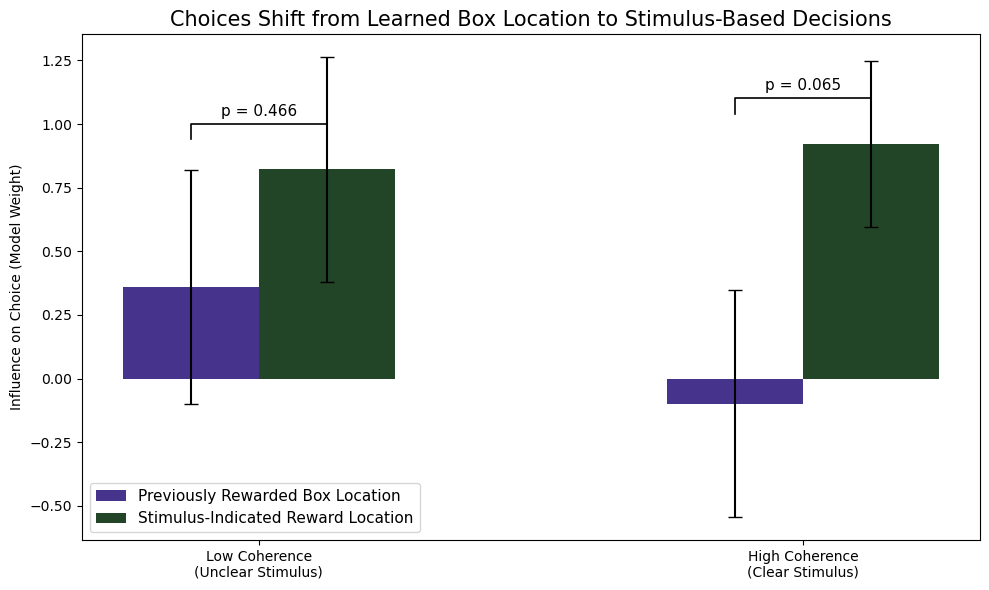

<Figure size 640x480 with 0 Axes>

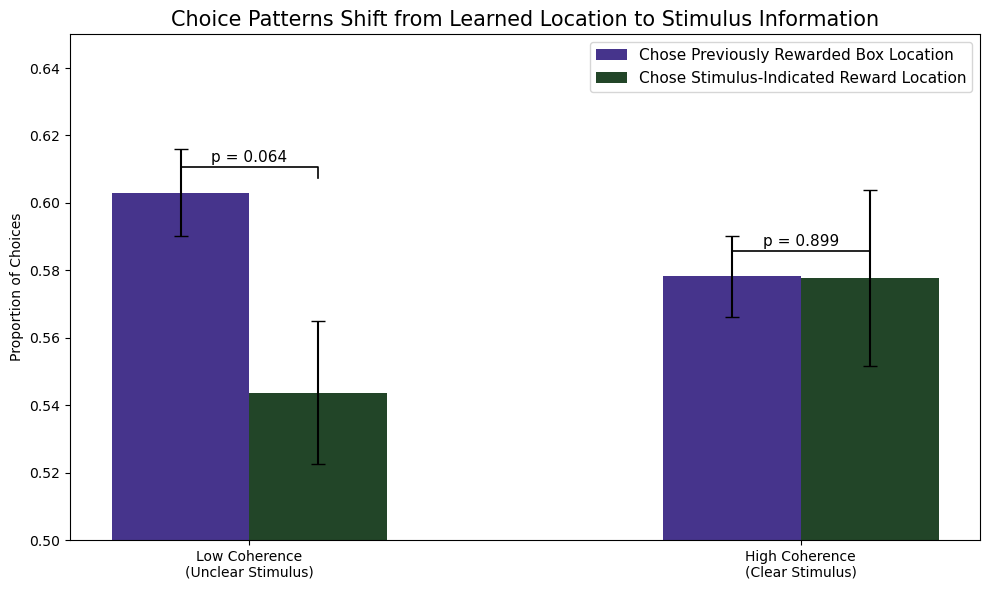

<Figure size 640x480 with 0 Axes>

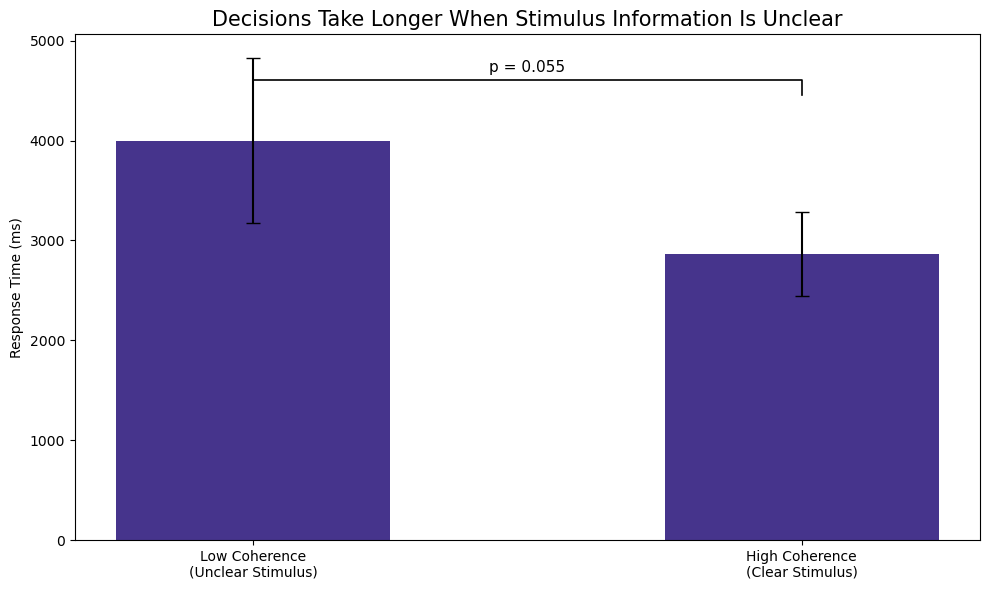

<Figure size 640x480 with 0 Axes>

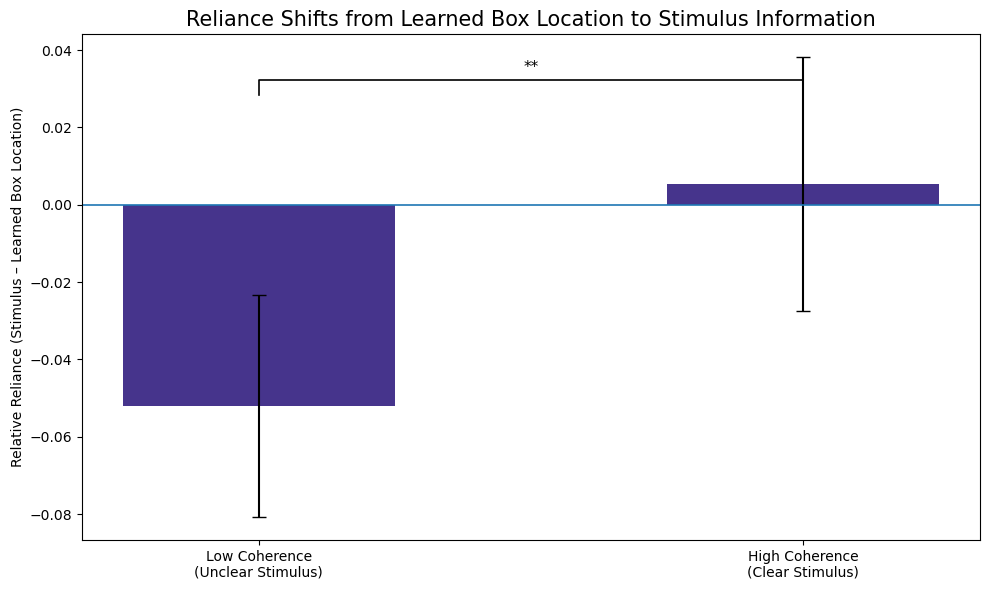

<Figure size 640x480 with 0 Axes>

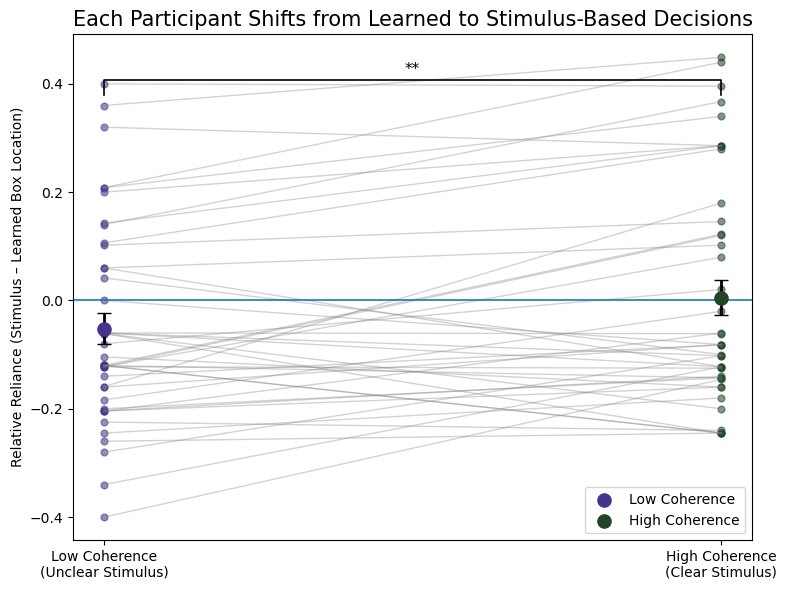

<Figure size 640x480 with 0 Axes>

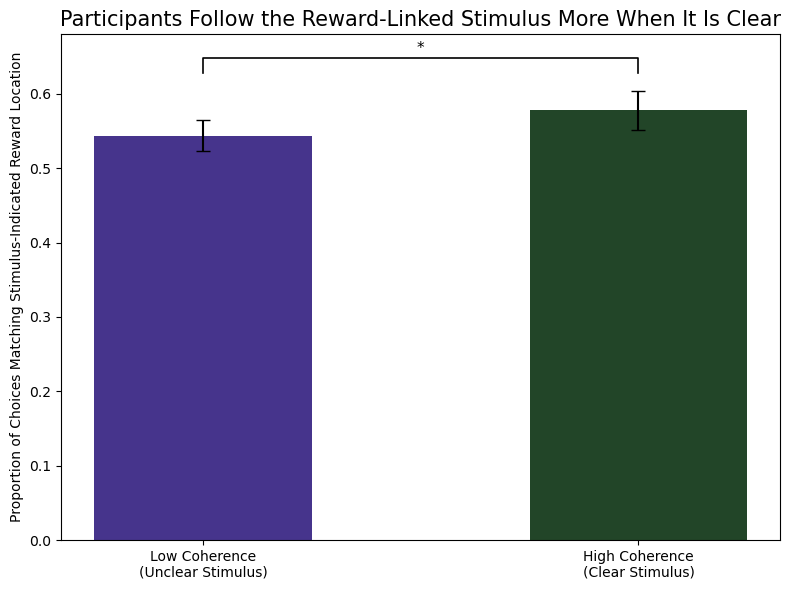

<Figure size 640x480 with 0 Axes>

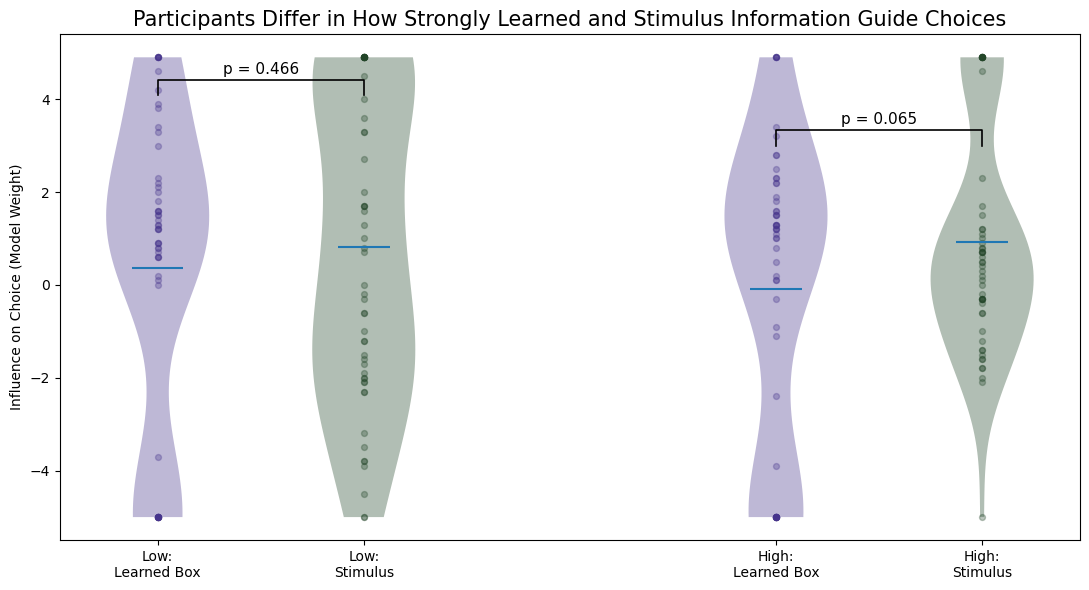

<Figure size 640x480 with 0 Axes>

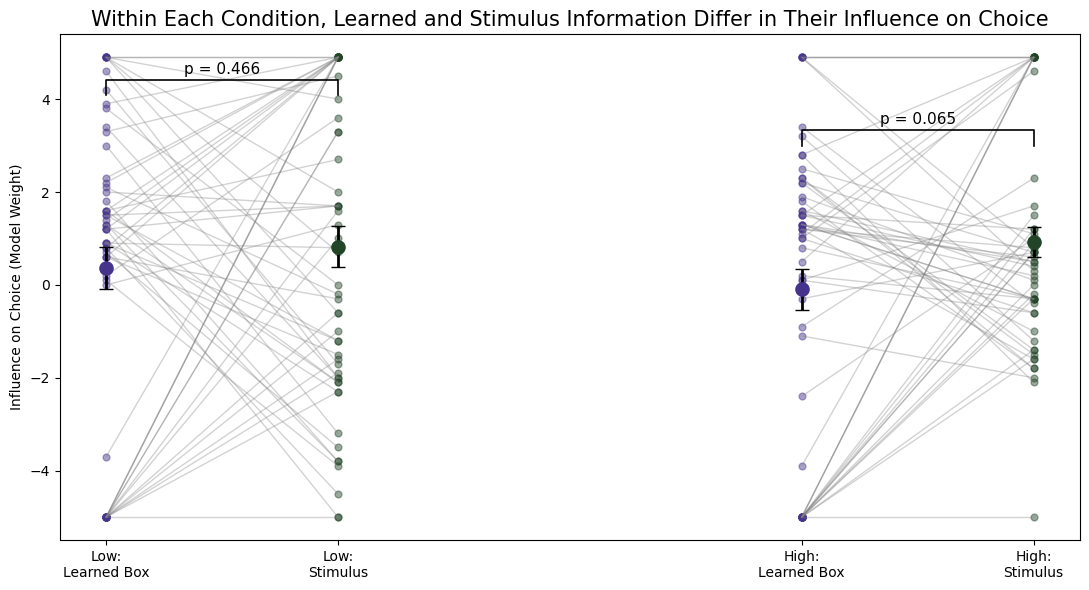

<Figure size 640x480 with 0 Axes>

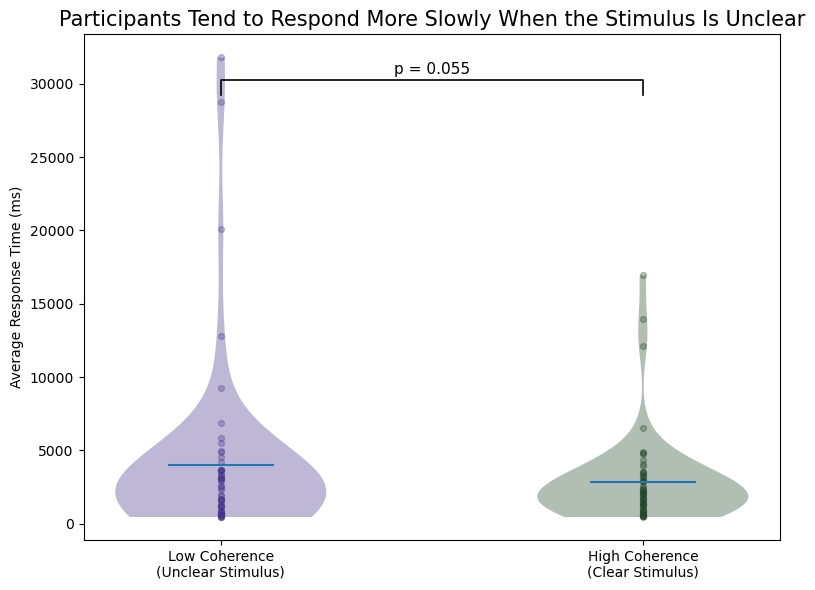

<Figure size 640x480 with 0 Axes>

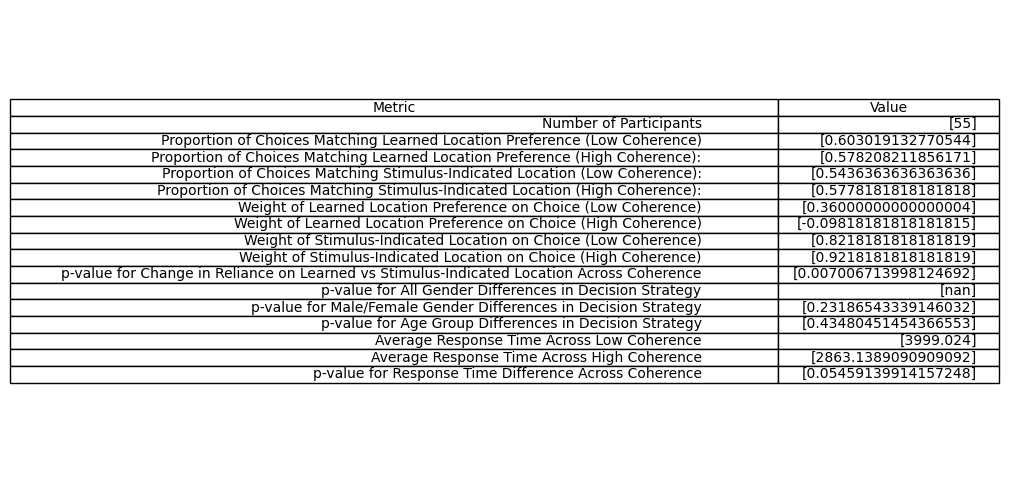

,Metric,Value
0,Number of Participants,[55]
1,Proportion of Choices Matching Learned Locatio...,[0.603019132770544]
2,Proportion of Choices Matching Learned Locatio...,[0.578208211856171]
3,Proportion of Choices Matching Stimulus-Indica...,[0.5436363636363636]
4,Proportion of Choices Matching Stimulus-Indica...,[0.5778181818181818]
5,Weight of Learned Location Preference on Choic...,[0.36000000000000004]
6,Weight of Learned Location Preference on Choic...,[-0.09818181818181815]
7,Weight of Stimulus-Indicated Location on Choic...,[0.8218181818181819]
8,Weight of Stimulus-Indicated Location on Choic...,[0.9218181818181819]
9,p-value for Change in Reliance on Learned vs S...,[0.007006713998124692]


In [21]:
rdk_bandit_csv_analysis('rdk_experiment_data (10).csv')